# Penugasan No. 3: Eksperimen Thresholding pada Citra `data.page()`

## Tujuan
Menerapkan dan membandingkan beberapa metode thresholding pada citra `data.page()`,
yaitu citra teks dokumen hitam-putih yang memiliki variasi pencahayaan tidak merata.

## Metode yang Dibandingkan
| Metode | Jenis | Cara Kerja |
|---|---|---|
| **Otsu** | Global | Mencari threshold optimal berdasarkan varians antar kelas |
| **Yen** | Global | Mencari threshold berdasarkan maksimasi entropi antar kelas |
| **Local (Adaptive)** | Lokal | Menghitung threshold berbeda untuk setiap region kecil citra |

## Mengapa `data.page()` Menarik untuk Diuji?
Citra `data.page()` adalah citra dokumen teks yang memiliki **variasi pencahayaan
tidak merata** (sebagian area lebih terang/gelap). Ini menjadi tantangan tersendiri
bagi metode thresholding global seperti Otsu dan Yen.

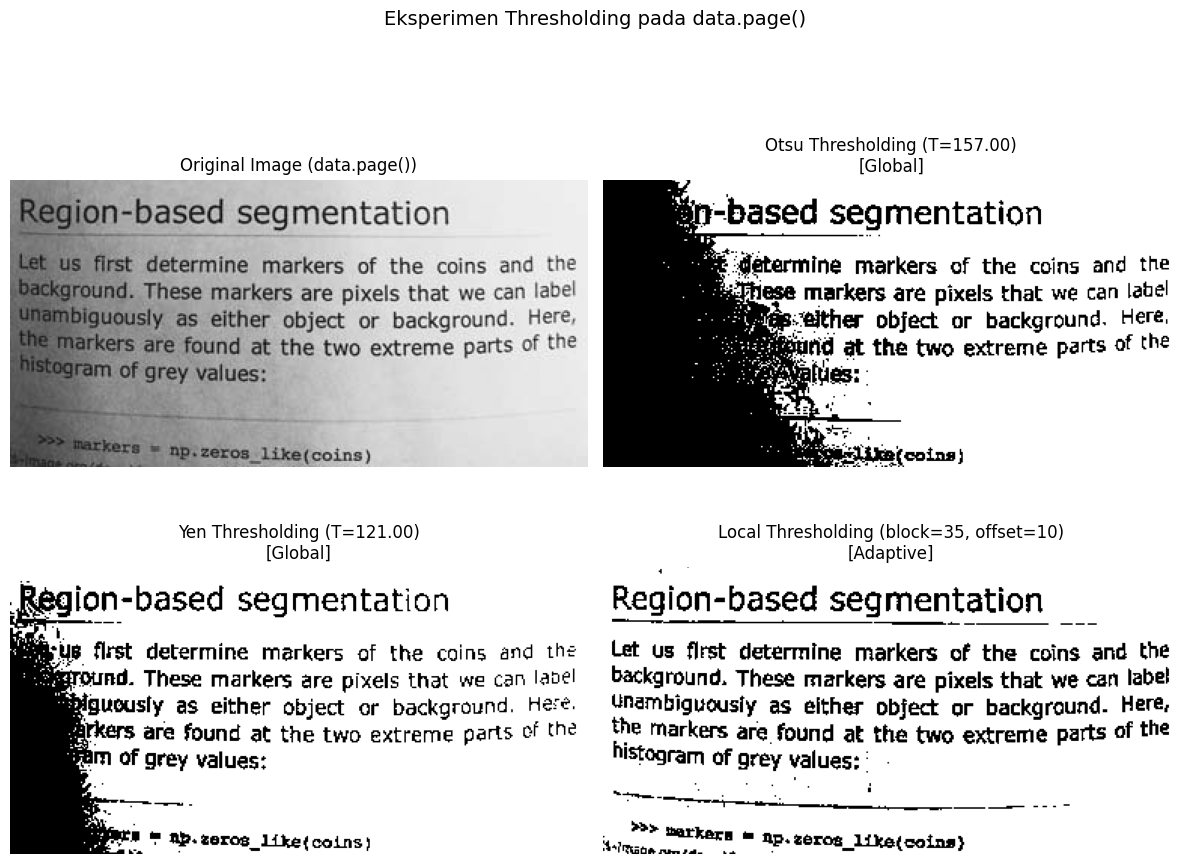

Nilai Threshold Otsu : 157.00
Nilai Threshold Yen  : 121.00


In [1]:
import matplotlib.pyplot as plt
from skimage import data, filters
from skimage.filters import threshold_otsu, threshold_yen, threshold_local

# 1. Memuat citra data.page()
image_page = data.page()

# 2. Thresholding Otsu (Global)
thresh_otsu = threshold_otsu(image_page)
binary_otsu = image_page > thresh_otsu

# 3. Thresholding Yen (Global)
thresh_yen = threshold_yen(image_page)
binary_yen = image_page > thresh_yen

# 4. Thresholding Local / Adaptive
# block_size: ukuran area lokal yang dihitung threshold-nya (harus angka ganjil)
# offset: nilai pengurang dari rata-rata lokal untuk menyesuaikan sensitivitas
block_size = 35
thresh_local = threshold_local(image_page, block_size, offset=10)
binary_local = image_page > thresh_local

# 5. Visualisasi Perbandingan
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
ax = axes.ravel()

ax[0].imshow(image_page, cmap=plt.cm.gray)
ax[0].set_title('Original Image (data.page())')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title(f'Otsu Thresholding (T={thresh_otsu:.2f})\n[Global]')
ax[1].axis('off')

ax[2].imshow(binary_yen, cmap=plt.cm.gray)
ax[2].set_title(f'Yen Thresholding (T={thresh_yen:.2f})\n[Global]')
ax[2].axis('off')

ax[3].imshow(binary_local, cmap=plt.cm.gray)
ax[3].set_title(f'Local Thresholding (block={block_size}, offset=10)\n[Adaptive]')
ax[3].axis('off')

plt.suptitle('Eksperimen Thresholding pada data.page()', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"Nilai Threshold Otsu : {thresh_otsu:.2f}")
print(f"Nilai Threshold Yen  : {thresh_yen:.2f}")

## Analisis Hasil

### Otsu Thresholding — Apakah hasilnya memuaskan?
**Kurang memuaskan.** Otsu menggunakan satu nilai threshold untuk seluruh citra.
Karena `data.page()` memiliki pencahayaan yang tidak merata, area yang lebih gelap
cenderung ikut terpotong sehingga sebagian teks menjadi hilang atau tidak terbaca
dengan baik.

### Yen Thresholding
Hasilnya mirip dengan Otsu karena sama-sama bersifat **global**. Nilai threshold
Yen biasanya sedikit lebih tinggi dari Otsu, sehingga hasil binerisasinya bisa
sedikit berbeda pada area abu-abu, namun tetap memiliki kelemahan yang sama
terhadap variasi pencahayaan.

### Local (Adaptive) Thresholding — Solusi Terbaik
**Paling memuaskan.** Metode lokal menghitung nilai threshold yang berbeda untuk
setiap region kecil (`block_size x block_size` piksel). Hasilnya jauh lebih baik
karena mampu beradaptasi terhadap variasi pencahayaan lokal — teks tetap terbaca
meskipun di area yang lebih gelap atau lebih terang sekalipun.

## Kesimpulan Penugasan No. 3

| Metode | Jenis | Hasil pada data.page() |
|---|---|---|
| Otsu | Global | Kurang memuaskan, teks di area gelap hilang |
| Yen | Global | Mirip Otsu, tidak jauh lebih baik |
| Local | Adaptif | Terbaik, teks tetap jelas di semua area |

**Kesimpulan utama:** Untuk citra dokumen dengan pencahayaan tidak merata seperti
`data.page()`, metode **thresholding lokal (adaptive)** jauh lebih unggul dibanding
metode global seperti Otsu maupun Yen. Metode global hanya cocok apabila
pencahayaan citra relatif seragam di seluruh area.